# Standardisation

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [63]:
df = pd.read_csv(r"C:\Users\Pranav Wadatkar\Desktop\Python\structured-learning\data\Social_Network_Ads.csv")

In [64]:
df = df.iloc[:,2:]

In [65]:
df.sample(5)

,Age,EstimatedSalary,Purchased
127,26,32000,0
177,25,22000,0
103,33,149000,1
0,19,19000,0
130,31,58000,0


In [66]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(df.drop(columns="Purchased"),
                                                        df["Purchased"],
                                                        test_size=0.20,
                                                        random_state=0)

x_train.shape, x_test.shape

((320, 2), (80, 2))

In [67]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

#scaler will learn the parameters by fiting train set to it
scaler.fit(x_train)

#transform train and test set
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [68]:
scaler.mean_

array([3.8218750e+01, 6.9928125e+04])

In [69]:
x_train_scaled = pd.DataFrame(x_train_scaled, columns=x_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled, columns=x_test.columns)

In [70]:
np.round(x_train.describe(),1)

,Age,EstimatedSalary
count,320.0,320.0
mean,38.2,69928.1
std,10.3,34570.1
min,18.0,15000.0
25%,30.0,43000.0
50%,38.0,69500.0
75%,46.0,88000.0
max,60.0,150000.0


In [71]:
np.round(x_train_scaled.describe(),1)

,Age,EstimatedSalary
count,320.0,320.0
mean,0.0,0.0
std,1.0,1.0
min,-2.0,-1.6
25%,-0.8,-0.8
50%,-0.0,-0.0
75%,0.8,0.5
max,2.1,2.3


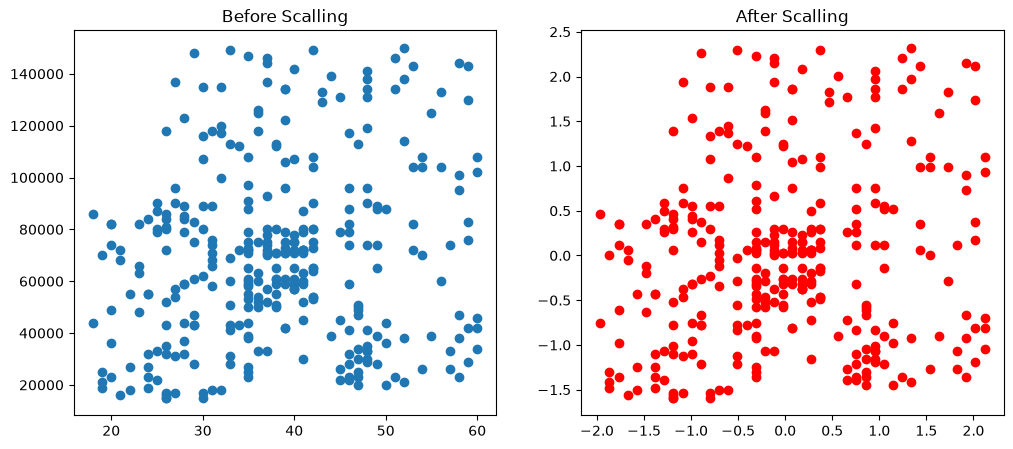

In [72]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(x_train["Age"],x_train["EstimatedSalary"])
ax1.set_title("Before Scalling")
ax2.scatter(x_train_scaled["Age"],x_train_scaled["EstimatedSalary"],color="Red")
ax2.set_title("After Scalling")
plt.show()

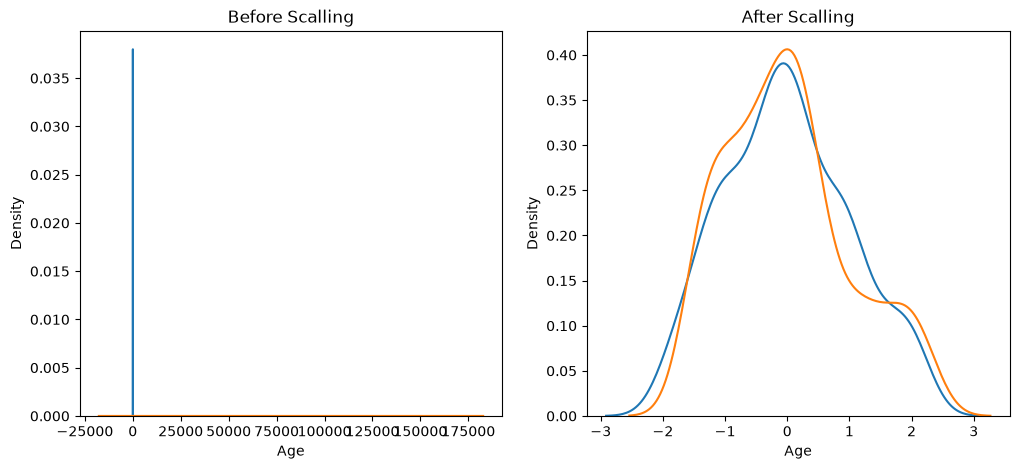

In [73]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.set_title("Before Scalling")
sns.kdeplot(x_train["Age"], ax= ax1)
sns.kdeplot(x_train["EstimatedSalary"], ax= ax1)

ax2.set_title("After Scalling")
sns.kdeplot(x_train_scaled["Age"], ax= ax2)
sns.kdeplot(x_train_scaled["EstimatedSalary"], ax= ax2)
plt.show()

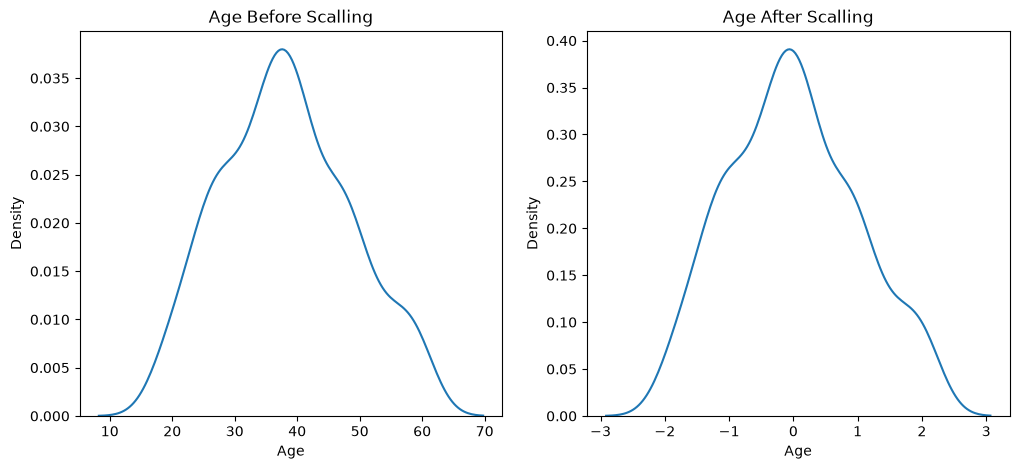

In [74]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.set_title("Age Before Scalling")
sns.kdeplot(x_train["Age"], ax= ax1)

ax2.set_title("Age After Scalling")
sns.kdeplot(x_train_scaled["Age"], ax= ax2)
plt.show()

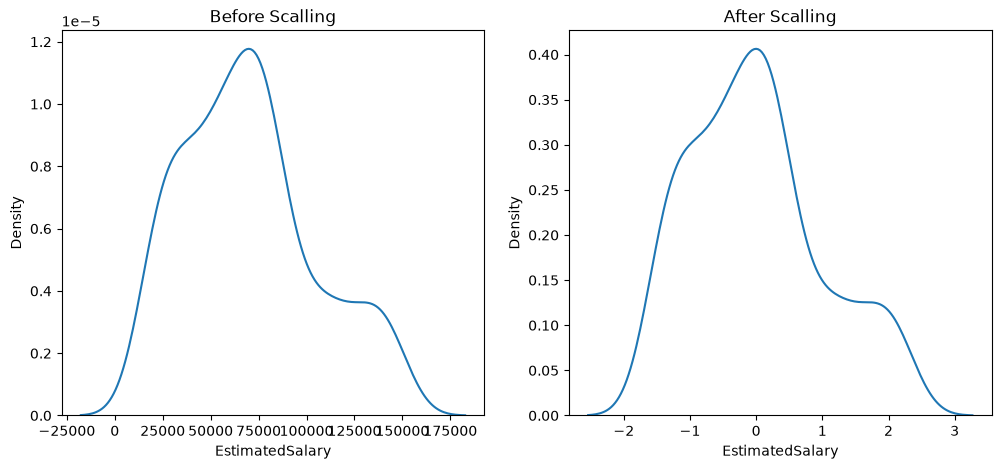

In [75]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.set_title("Before Scalling")
sns.kdeplot(x_train["EstimatedSalary"], ax= ax1)

ax2.set_title("After Scalling")
sns.kdeplot(x_train_scaled["EstimatedSalary"], ax= ax2)
plt.show()

In [76]:
from sklearn.linear_model import LogisticRegression

In [77]:
lr = LogisticRegression()
lr_scaled = LogisticRegression()

In [78]:
lr.fit(x_train,y_train)
lr_scaled.fit(x_train_scaled,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

In [79]:
y_pred = lr.predict(x_test)
y_pred_scaled = lr_scaled.predict(x_test_scaled)

In [80]:
from sklearn.metrics import accuracy_score

In [81]:
print("Actual", accuracy_score(y_test,y_pred))
print("Scaled", accuracy_score(y_test,y_pred_scaled))

Actual 0.9125
Scaled 0.925


# Normalisation

a) minmaxscaling

In [86]:
wine_df = pd.read_csv(r"C:\Users\Pranav Wadatkar\Desktop\Python\structured-learning\data\wine_data.csv",header=None, usecols=[0,1,2])

wine_df.columns=["Class label", "Alcohol", "Malic Acid"]

In [87]:
wine_df

,Class label,Alcohol,Malic Acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


In [88]:
x_train, x_test, y_train, y_test = train_test_split(wine_df.drop("Class label", axis=1),
                                                    wine_df["Class label"],
                                                    test_size=0.20,
                                                    random_state=0)

x_train.shape, x_test.shape

((142, 2), (36, 2))

In [89]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaler.fit(x_train)

#transform
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [93]:
x_train_scaled = pd.DataFrame(x_train_scaled, columns=x_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled, columns=x_test.columns)

In [94]:
np.round(x_train.describe(), 1)

,Alcohol,Malic Acid
count,142.0,142.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.7
25%,12.3,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


In [95]:
np.round(x_train_scaled.describe(), 1)

,Alcohol,Malic Acid
count,142.0,142.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


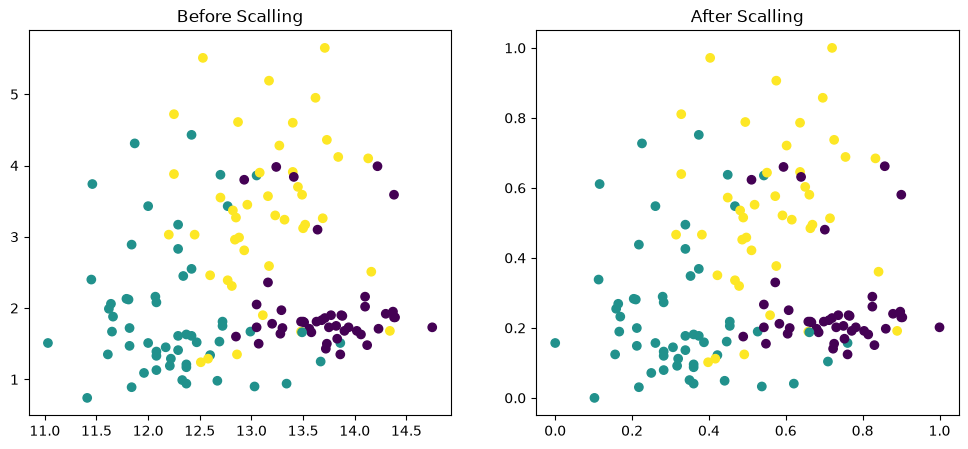

In [99]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(x_train["Alcohol"],x_train["Malic Acid"], c=y_train)
ax1.set_title("Before Scalling")
ax2.scatter(x_train_scaled["Alcohol"],x_train_scaled["Malic Acid"],c=y_train)
ax2.set_title("After Scalling")
plt.show()

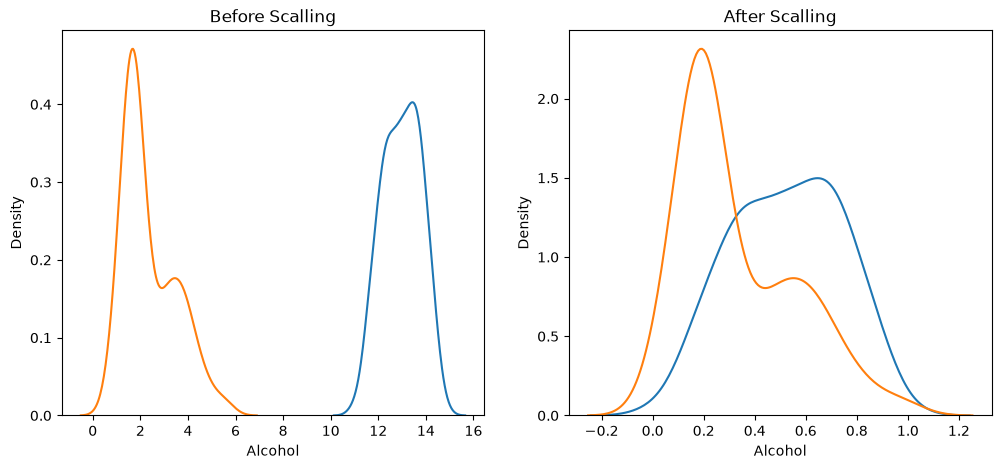

In [101]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.set_title("Before Scalling")
sns.kdeplot(x_train["Alcohol"], ax= ax1)
sns.kdeplot(x_train["Malic Acid"], ax= ax1)

ax2.set_title("After Scalling")
sns.kdeplot(x_train_scaled["Alcohol"], ax= ax2)
sns.kdeplot(x_train_scaled["Malic Acid"], ax= ax2)
plt.show()

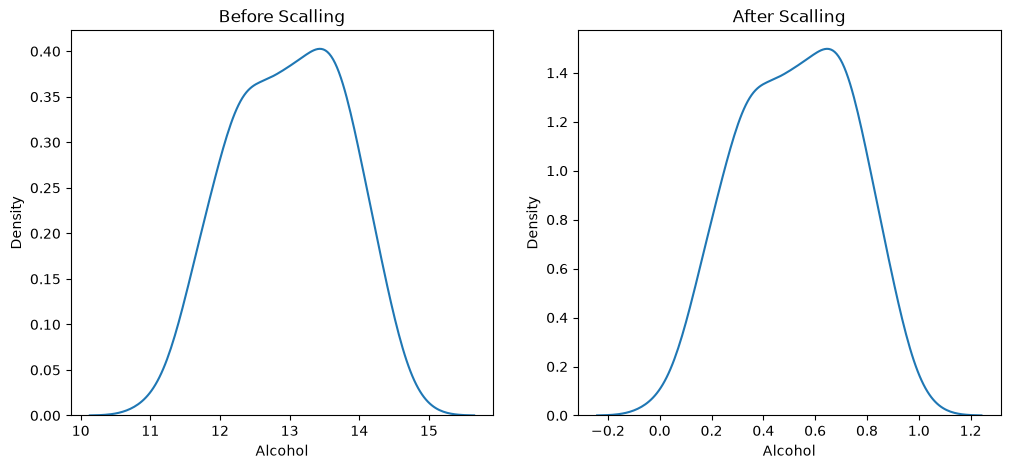

In [103]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.set_title("Before Scalling")
sns.kdeplot(x_train["Alcohol"], ax= ax1)

ax2.set_title("After Scalling")
sns.kdeplot(x_train_scaled["Alcohol"], ax= ax2)
plt.show()

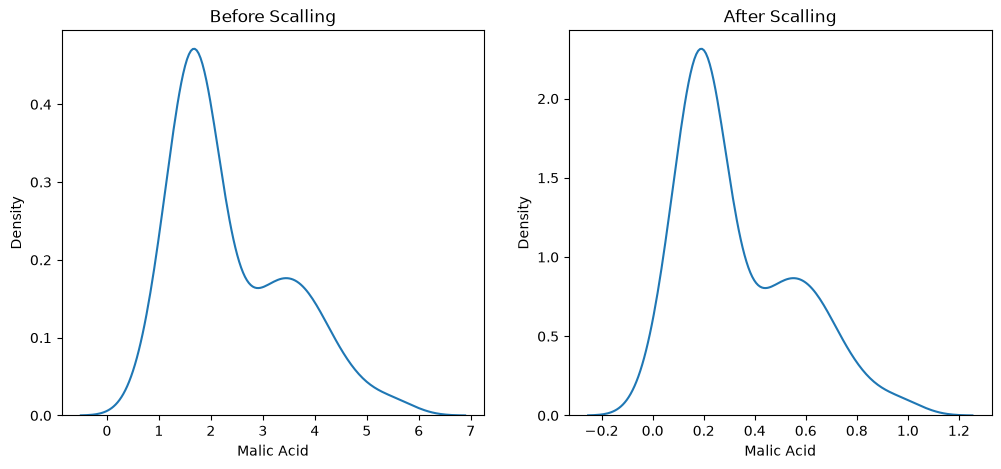

In [104]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.set_title("Before Scalling")
sns.kdeplot(x_train["Malic Acid"], ax= ax1)

ax2.set_title("After Scalling")
sns.kdeplot(x_train_scaled["Malic Acid"], ax= ax2)
plt.show()

Mean Normalisation

In [ ]:
#no sklearn class performed using formula